In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)
print('Imports Successfully!')

Imports Successfully!


In [ ]:
DATA_PATH = "../data/processed/final_merged_labeled_dataset.csv" 

df = pd.read_csv(DATA_PATH)

META_COLS = ['company', 'date', 'quarter', 'layoff','same_quarter', 'next_quarter', 'layoff_same_quarter', 'layoff_next_quarter', 'layoff_same_or_next_quarter','source_pool','layoff_this_quarter','layoff_next_quarter','layoff_this_or_next_quarter']
FEATURE_COLS = [col for col in df.columns if col not in META_COLS]
TARGET_COL  = 'layoff'

n_companies  = df['company'].nunique()
n_rows_pos   = len(df[df['layoff'] == 1])
n_rows_neg   = len(df[df['layoff'] == 0])

print(f'Positive companies : {n_companies}')
print(f'Positive rows      : {n_rows_pos}')
print(f'Negative rows      : {n_rows_neg}')
print(f'Feature columns    : {len(FEATURE_COLS)}')
print(f'Quarters present   : {sorted(df["quarter"].unique())}')
df.head(5)

Positive companies : 5381
Positive rows      : 1205
Negative rows      : 28813
Feature columns    : 348
Quarters present   : ['2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1', '2026Q2']


,company,date,quarter,bs_Accounts Payable,bs_Accounts Receivable,bs_Accrued Interest Receivable,bs_Accumulated Depreciation,bs_Additional Paid In Capital,bs_Allowance For Doubtful Accounts Receivable,bs_Assets Held For Sale Current,...,fin_Total Operating Income As Reported,fin_Total Other Finance Cost,fin_Total Revenue,fin_Total Unusual Items,fin_Total Unusual Items Excluding Goodwill,fin_Write Off,layoff_this_quarter,layoff_next_quarter,layoff,source_pool
0,AFCONS.BO,2024-09-30,2024Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,layoff_tracked
1,AFCONS.BO,2024-12-31,2024Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,0,0,0,layoff_tracked
2,AFCONS.BO,2025-03-31,2025Q1,3.541350e+10,2.779320e+10,NaN,-3.305210e+10,1.384480e+10,-490400000.0,NaN,...,NaN,NaN,3.223270e+10,0.0,0.0,NaN,0,0,0,layoff_tracked
3,AFCONS.BO,2025-06-30,2025Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.370380e+10,NaN,NaN,NaN,0,0,0,layoff_tracked
4,AFCONS.BO,2025-09-30,2025Q3,3.540080e+10,2.908470e+10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.988390e+10,NaN,NaN,NaN,0,0,0,layoff_tracked


In [3]:
# Combine real positives + negatives (randomly sampled) into a single dataframe for training/testing

presence_df = df[FEATURE_COLS].notna().astype(int)  # 1 if present, 0 if NaN
presence_df.columns = [f'HAS_{c}' for c in FEATURE_COLS]

# Drop zero-variance presence columns (allways 0 or 1)
# WHY? Because they don't provide any signal to distinguish between classes if they are always 0 or always 1.
pvar = presence_df.var()
presence_df = presence_df.loc[:, pvar > 0]
print(f"Presence features after removing zero variance: {presence_df.shape[1]} columns  ")

Presence features after removing zero variance: 347 columns  


In [4]:
numeric_df = df[FEATURE_COLS].copy()
col_medians = numeric_df.median()
numeric_df = numeric_df.fillna(col_medians)

# Drop any column still having all-NaN:
still_nan = numeric_df.columns[numeric_df.isnull().any()]
if len(still_nan) > 0:
    print(f"Dropping {len(still_nan)} columns with all-NaN values: {list(still_nan)}")
    numeric_df = numeric_df.drop(columns=still_nan)
# Do we need to drop HAS_ columns with all-NaN?
# No, they are binary indicators of presence, so they should not be dropped even if all 0 or 1 in one class.

# Drop zero variance numeric columns (constant value after median interpolation)
nvar= numeric_df.var()
numeric_df = numeric_df.loc[:, nvar > 0]
print(f"Numeric features after removing zero variance: {numeric_df.shape[1]} columns  ")


Numeric features after removing zero variance: 347 columns  


In [5]:
x = pd.concat([numeric_df.reset_index(drop=True), presence_df.reset_index(drop=True)], axis=1)
y = df['layoff'].reset_index(drop=True)

assert x.isnull().sum().sum() == 0, "There should be no NaN values in the final feature set"
print(f'Final feature set shape: {x.shape}')
print(f'feature matrix : {y.value_counts().to_dict()}')
print(f'No NaN values')

Final feature set shape: (30018, 694)
feature matrix : {0: 28813, 1: 1205}
No NaN values


In [6]:
# Stratified split — preserves 1:1 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale for distance/linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train label dist : {y_train.value_counts().to_dict()}')
print(f'Test  label dist : {y_test.value_counts().to_dict()}')

Train: 24014 rows  |  Test: 6004 rows
Train label dist : {0: 23050, 1: 964}
Test  label dist : {0: 5763, 1: 241}


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# (name, model, use_scaled)
models = [
    ('Random Forest',      RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE), False),
    ('XGBoost',            XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0), False),
    ('Gradient Boosting',  GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    ('Logistic Regression',LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE), True),
    ('SVM',                SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE), True),
    ('KNN',                KNeighborsClassifier(n_neighbors=20), True),
]

results = []
for name, model, scaled in models:
    Xtr = X_train_sc if scaled else X_train
    Xte = X_test_sc  if scaled else X_test

    cv_auc = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    lbl = str(int(y_test.unique()[0])) if y_test.nunique() == 1 else '1'
    pos_rep = rep.get('1', rep.get('1.0', {}))

    results.append({
        'Model':          name,
        'CV AUC':         f"{cv_auc.mean():.3f} ± {cv_auc.std():.3f}",
        'CV AUC mean':    cv_auc.mean(),
        'CV AUC std':     cv_auc.std(),
        'Test AUC':       test_auc,
        'Accuracy':       rep['accuracy'],
        'Precision (1)':  pos_rep.get('precision', 0),
        'Recall (1)':     pos_rep.get('recall', 0),
        'F1 (1)':         pos_rep.get('f1-score', 0),
        '_model': model, '_scaled': scaled, '_y_pred': y_pred, '_y_prob': y_prob
    })
    print(f'{name:25s}  CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}  |  Test AUC: {test_auc:.3f}  |  Acc: {rep["accuracy"]:.3f}')

print('All models done')

Random Forest              CV AUC: 0.928 ± 0.011  |  Test AUC: 0.939  |  Acc: 0.975
XGBoost                    CV AUC: 0.893 ± 0.017  |  Test AUC: 0.910  |  Acc: 0.984
Gradient Boosting          CV AUC: 0.899 ± 0.021  |  Test AUC: 0.922  |  Acc: 0.980
Logistic Regression        CV AUC: 0.863 ± 0.021  |  Test AUC: 0.895  |  Acc: 0.875
SVM                        CV AUC: 0.883 ± 0.015  |  Test AUC: 0.896  |  Acc: 0.943
KNN                        CV AUC: 0.871 ± 0.015  |  Test AUC: 0.879  |  Acc: 0.968
All models done


Model Performance Summary:
              Model        CV AUC  Test AUC  Accuracy  Precision (1)  Recall (1)   F1 (1)
      Random Forest 0.928 ± 0.011  0.939266  0.975017       0.757062    0.556017 0.641148
  Gradient Boosting 0.899 ± 0.021  0.921668  0.980180       0.827957    0.639004 0.721311
            XGBoost 0.893 ± 0.017  0.910366  0.983678       0.938650    0.634855 0.757426
                SVM 0.883 ± 0.015  0.896083  0.943205       0.376847    0.634855 0.472952
Logistic Regression 0.863 ± 0.021  0.894540  0.875416       0.208285    0.751037 0.326126
                KNN 0.871 ± 0.015  0.879178  0.967688       1.000000    0.195021 0.326389


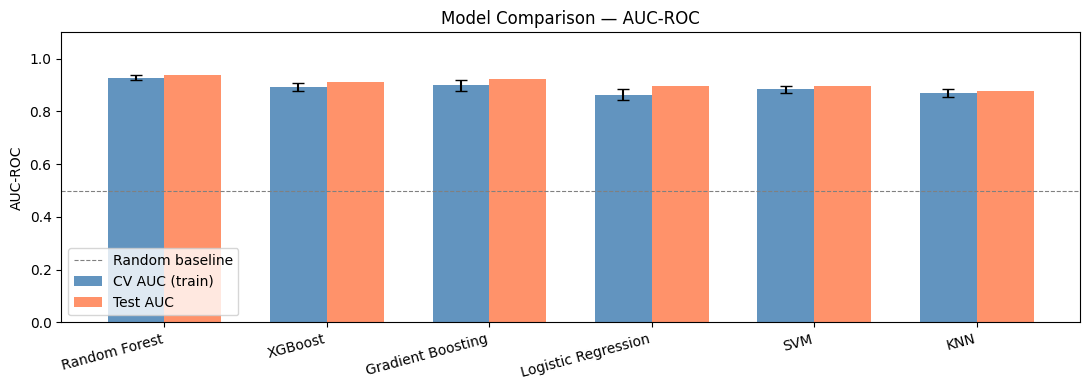

In [8]:
display_cols = ['Model','CV AUC','Test AUC','Accuracy','Precision (1)','Recall (1)','F1 (1)']
results_df = pd.DataFrame(results)[display_cols].sort_values('Test AUC', ascending=False).reset_index(drop=True)
print("Model Performance Summary:")
print(results_df.to_string(index=False))

# Bar chart: CV AUC vs Test AUC
cv_means = [r['CV AUC mean'] for r in results]
cv_stds  = [r['CV AUC std']  for r in results]
test_aucs = [r['Test AUC']   for r in results]
names     = [r['Model']      for r in results]

x_plt = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x_plt - w/2, cv_means,  w, yerr=cv_stds, label='CV AUC (train)', color='steelblue', alpha=0.85, capsize=4)
ax.bar(x_plt + w/2, test_aucs, w, label='Test AUC', color='coral', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_xticks(x_plt)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUC-ROC')
ax.set_title('Model Comparison — AUC-ROC')
ax.legend()
plt.tight_layout()
plt.show()



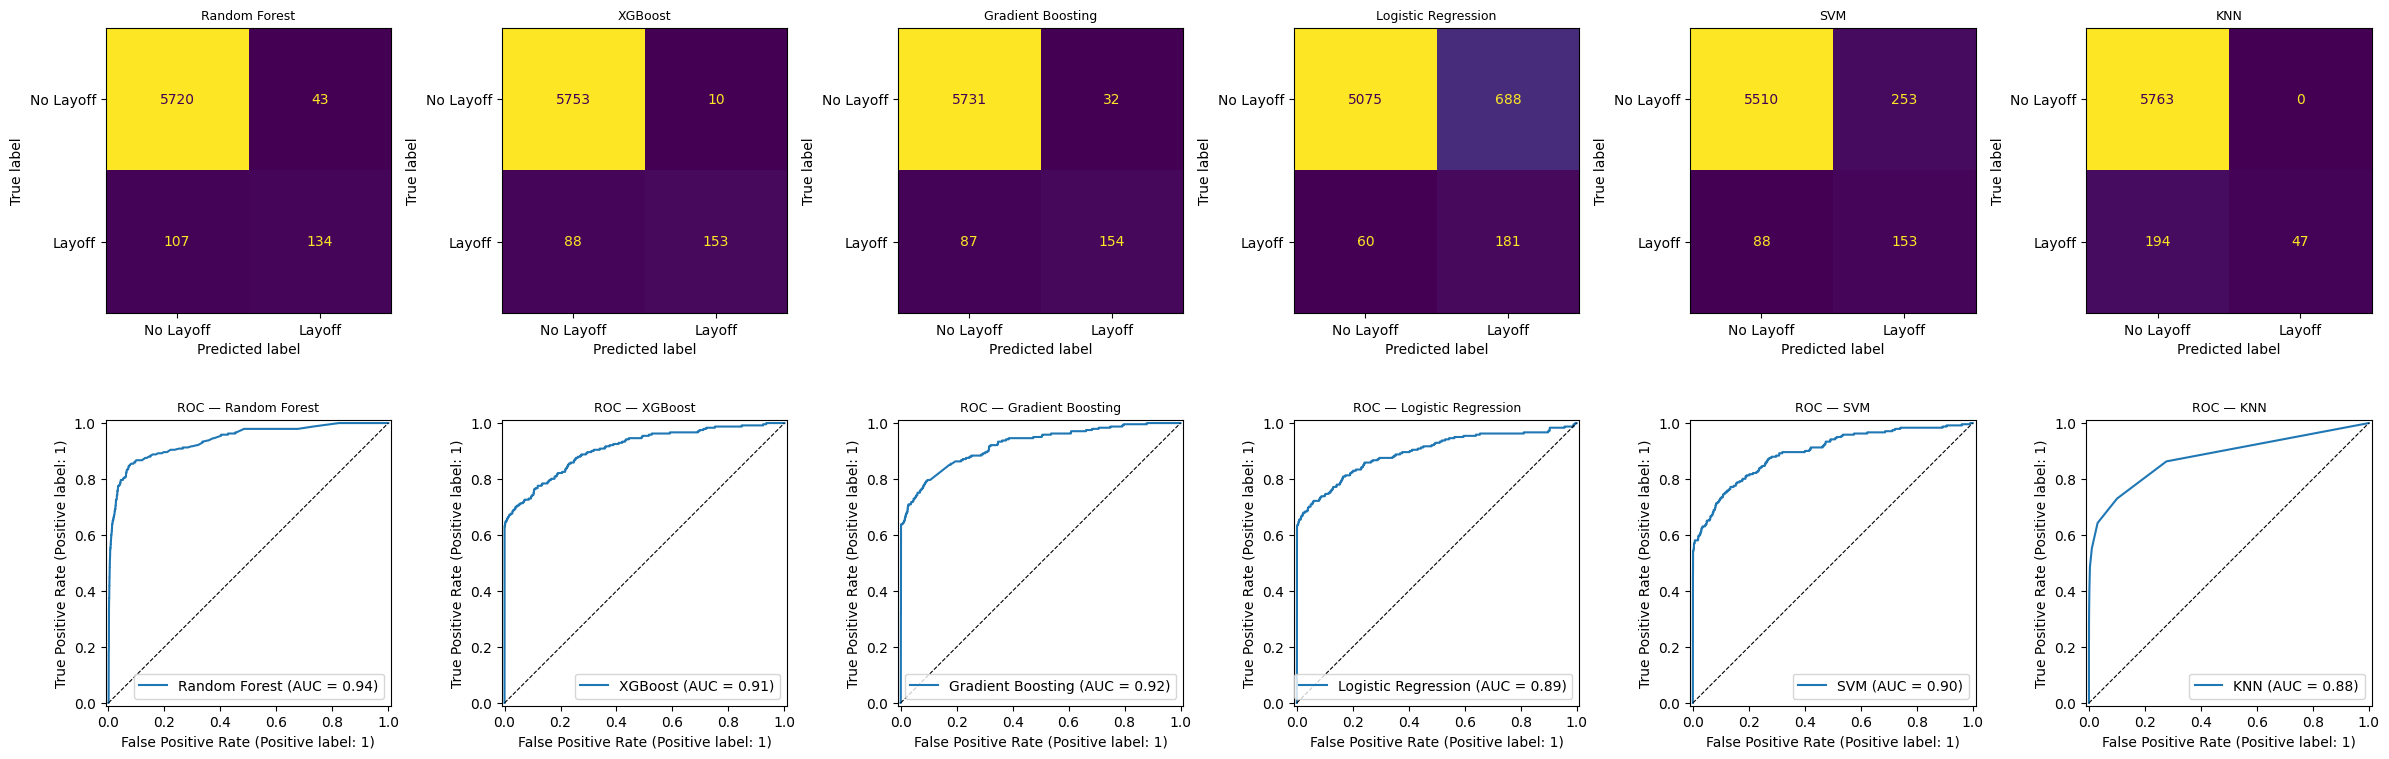

In [9]:
n = len(results)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
for i, r in enumerate(results):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, r['_y_pred']),
        display_labels=['No Layoff', 'Layoff']
    ).plot(ax=axes[0, i], colorbar=False)
    axes[0, i].set_title(r['Model'], fontsize=9)

    RocCurveDisplay.from_predictions(y_test, r['_y_prob'], ax=axes[1, i], name=r['Model'])
    axes[1, i].plot([0,1],[0,1],'k--',linewidth=0.8)
    axes[1, i].set_title('ROC — ' + r['Model'], fontsize=9)

plt.tight_layout()
plt.show()

Feature importance from: Random Forest (Test AUC = 0.939)


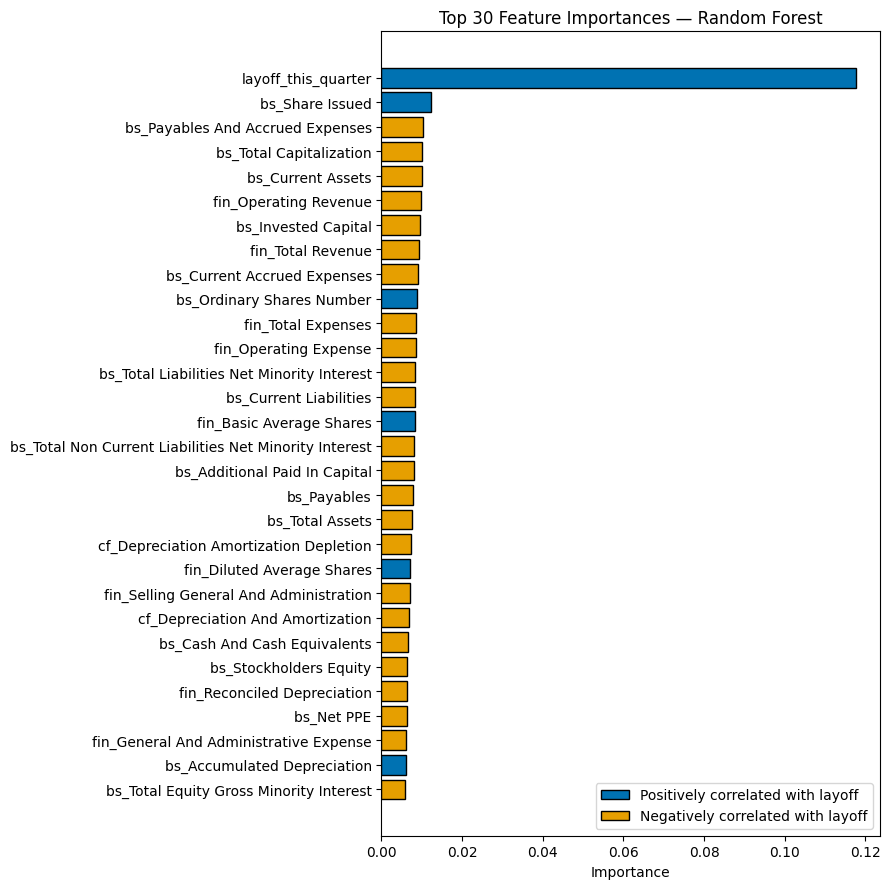

Top 30 features:
layoff_this_quarter                                       0.117718
bs_Share Issued                                           0.012230
bs_Payables And Accrued Expenses                          0.010313
bs_Total Capitalization                                   0.010137
bs_Current Assets                                         0.010085
fin_Operating Revenue                                     0.009820
bs_Invested Capital                                       0.009524
fin_Total Revenue                                         0.009189
bs_Current Accrued Expenses                               0.009035
bs_Ordinary Shares Number                                 0.008785
fin_Total Expenses                                        0.008645
fin_Operating Expense                                     0.008642
bs_Total Liabilities Net Minority Interest                0.008393
bs_Current Liabilities                                    0.008325
fin_Basic Average Shares                     

In [10]:
tree_results = [r for r in results if hasattr(r['_model'], 'feature_importances_')]
best = max(tree_results, key=lambda r: r['Test AUC'])
print(f'Feature importance from: {best["Model"]} (Test AUC = {best["Test AUC"]:.3f})')

importances = pd.Series(best['_model'].feature_importances_, index=X_train.columns)
top30 = importances.nlargest(30)

# Direction of each feature's relationship to the target (correlation sign),
# since tree feature_importances_ only capture magnitude, not direction.
corr_with_target = x[top30.index].corrwith(y)
colors = corr_with_target.reindex(top30.index).apply(lambda c: '#0072B2' if c > 0 else '#E69F00')

fig, ax = plt.subplots(figsize=(9, 9))
top30_sorted = top30.sort_values()
ax.barh(top30_sorted.index, top30_sorted.values,
        color=colors.reindex(top30_sorted.index), edgecolor='black')
ax.set_title(f'Top 30 Feature Importances — {best["Model"]}')
ax.set_xlabel('Importance')

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#0072B2', edgecolor='black', label='Positively correlated with layoff'),
    Patch(facecolor='#E69F00', edgecolor='black', label='Negatively correlated with layoff'),
]
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.show()

print('Top 30 features:')
print(top30.head(30).to_string())

In [11]:
best_overall = max(results, key=lambda r: r['Test AUC'])
print(f'=== Best Model: {best_overall["Model"]} ===')
print(f'Test AUC : {best_overall["Test AUC"]:.4f}')
print(f'CV AUC   : {best_overall["CV AUC"]}')
print()
print(classification_report(
    y_test, best_overall['_y_pred'],
    target_names=['No Layoff', 'Layoff'], zero_division=0
))

=== Best Model: Random Forest ===
Test AUC : 0.9393
CV AUC   : 0.928 ± 0.011

              precision    recall  f1-score   support

   No Layoff       0.98      0.99      0.99      5763
      Layoff       0.76      0.56      0.64       241

    accuracy                           0.98      6004
   macro avg       0.87      0.77      0.81      6004
weighted avg       0.97      0.98      0.97      6004



In [12]:
best_model  = best_overall['_model']

mask       = df['layoff'] == 1
X_real     = x.loc[mask]
X_real_inp = scaler.transform(X_real) if scaled else X_real

df_scored = df.loc[mask, ['company', 'date', 'quarter']].copy()
df_scored['layoff_prob'] = best_model.predict_proba(X_real_inp)[:, 1]
df_scored['predicted']   = best_model.predict(X_real_inp)
df_scored = df_scored.sort_values('layoff_prob', ascending=False).reset_index(drop=True)

print('Top 100-scored company-quarters:')
df_scored.head(100)

Top 100-scored company-quarters:


,company,date,quarter,layoff_prob,predicted
0,RAD.CN,2025-02-28,2025Q1,0.410000,0
1,MVMD.CN,2025-03-31,2025Q1,0.406667,0
2,ADNT,2025-06-30,2025Q2,0.403333,0
3,PTON,2025-09-30,2025Q3,0.403333,0
4,Q3Q.F,2025-04-30,2025Q2,0.400000,0
...,...,...,...,...,...
95,CHTR,2025-03-31,2025Q1,0.383333,0
96,PRTS,2025-06-30,2025Q2,0.383333,0
97,DBX,2024-12-31,2024Q4,0.383333,0
98,BBY,2026-01-31,2026Q1,0.383333,0
